# ARGUS-FEDER — Building a training cohort for ELM forecasting

This notebook shows **ARGUS**, a notebook-native AI agent, working on a real
research question taken from a paper published this year. Every question is
typed in plain English into a `%%ask` cell. The agent decides what to look up,
writes and runs its own code, and reports back. **Nothing here requires the
reader to write code.**

Run Steps 1-5 below once, then run the questions in order.

## The question, and where it comes from

Teo et al. (April 2026) trained a neural network to **forecast the first ELM**
after the L-H transition in DIII-D, using Doppler backscattering data. The
model gives a useful warning roughly 100 ms ahead — enough time for
ELM-mitigation coils, which need about 50 ms.

The paper is explicit about what limits it. In its own words:

> *"Due to the limited size of the dataset used for training and testing, it is
> difficult to reliably quantify the model performance."*

> *"To improve model generality … an important step is to identify which types
> of discharges will be relevant for training and add these shots to the
> training dataset."*

They trained, validated and tested on **26 shots**.

**So this notebook asks the obvious follow-up question: across the DIII-D
archive, which discharges would make good training data?** That is a search
problem over stored ELM labels, and it is exactly what a scientist would want
to answer before committing to a modelling campaign — without writing any code.

## What it is answering from

Stored ELM labels for roughly ten thousand DIII-D discharges, recording when
individual ELMs fired and when the plasma was in an ELMy phase, together with
which method produced each label. The raw D-alpha traces themselves are
fetched on demand from the Pelican mirror of the DIII-D archive.

#### Step 1 — Prepare your session (one-time)

Run the cell below. **Your session will restart automatically — that's
expected.** Once it restarts, continue to Step 2.

In [1]:
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/25.11.0-1/Miniforge3-25.11.0-1-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:10
🔁 Restarting kernel...


#### Step 2 — Choose your AI model

Pick one and run the cell.

In [1]:
# Use GLM-5 from National Research Platform
# LLM = {
#     "model": "glm-5",
#     "url": "https://ellm.nrp-nautilus.io/v1",
#     "api_key_env": "NRP_API_KEY",
# }

# Use GPT-5.5 from OpenAI
# LLM = {
#     "model": "gpt-5.5",
#     "api_key_env": "OPENAI_API_KEY",
# }

# Use Claude Sonnet 4.6 from Anthropic
# LLM = {
#     "model": "claude-sonnet-4-6",
#     "api_key_env": "ANTHROPIC_API_KEY",
#     "flavor": "anthropic",
# }

# Use GLM-5 from ZAI
LLM = {
    "model": "glm-5",
    "url": "https://api.z.ai/api/coding/paas/v4",
    "api_key_env": "ZAI_API_KEY",
}

#### Step 3 — Add your keys

Click the key icon in the left sidebar and add your secrets (toggle
"Notebook access" on for each):

- The API key matching what you picked in Step 2 (e.g. `ZAI_API_KEY`)
- Your DIII-D Pelican access token, named `FDP_TOKEN`. **This one is required
  here** — question 5 fetches a raw D-alpha trace from the archive.

#### Step 4 — Install ARGUS-FEDER

In [2]:
import urllib.request
exec(urllib.request.urlopen(
    'https://raw.githubusercontent.com/klinucsd/argus_feder/main/install.py'
).read().decode(), globals())

Setting up ARGUS-FEDER...
  • Installing DIII-D data access (~1-2 min, one-time)
    ..............
    .....
  • DIII-D data access ready
  • Pelican token loaded
  • Installing the ARGUS agent (~1 min the first time)
ARGUS bootstrap starting...
  ✓ Wrote LLM config to /root/.deepagents/config.toml (added default params for 1 ChatOpenAI provider(s))
  ✓ Loaded ZAI_API_KEY from Colab Secrets
  · Installing ARGUS dependencies (~30–90 s the first time)...
  ✓ ARGUS dependencies installed
  ✓ Downloaded sage_magic.py + sage_kernel_backend.py from main
  ✓ Installed 16 core skill(s) into /root/.deepagents/agent/skills: arcgis-feature-skill-builder, array-skill-builder, ckan-skill-builder, local-skill-builder, ndp-search, ndp-skill-builder, repo-skill-builder, s3-skill-builder, sage-bbox-map, sage-dropdown, sage-metrics, skillsmp, tabular-skill-builder, us-counties, us-states, zenodo-skill-builder

ARGUS ready — %%ask, %%mcp, %%skill are registered.
  Provider: llm  ·  Model: llm:glm-5
  • 

In [ ]:
%reset

#### Step 5 — Upload the data files

The questions read from two SQLite files, neither bundled with the installer.
Open the **file browser** (folder icon, left sidebar) and drag both in; they
land in `/content/`, where the skills look automatically.

| file | size | needed for |
|---|---|---|
| `elm.sqlite` | ~150 MB | every question |
| `d3drdb_demo.sqlite` | ~55 MB | question 6, which checks the shot database for an L-H transition field |

Keep the filenames exactly as shown. The upload takes a few minutes and **must
be repeated for each fresh Colab session** — Colab clears `/content/` when the
session ends.

## 1. What labels exist, and who made them?

Before using labels to select shots, establish what they are. A training set is
only as good as the labels behind it, and "an ELM" means whatever the method
that produced it says it means.

**Expect:** several label sets distinguished — detector output and hand-made
labels — each attributed to a source and a version, and a clear statement that
individual ELMs and ELMy phases are different things.

I'll consult the `d3d-elm-index` skill, which covers ELM labels and detection methods for DIII-D.

This is a `d3d-elm-index` question about detector provenance and coverage — the skill says to call `label_sets()` for shot counts and `runs()` for provenance. Writing the query script now.

The data is complete — four distinct methods across five runs. I'll make a quick coverage chart (colored by source type: detector vs hand-labelled ground truth) before writing up.

Both scripts ran clean on the first pass. Here's the full picture, with every number quoted from the query output above.

## ELM labelling methods available for DIII-D

Four distinct methods are stored, across five label sets (the GA detector is stored twice, at two granularities). Coverage chart:


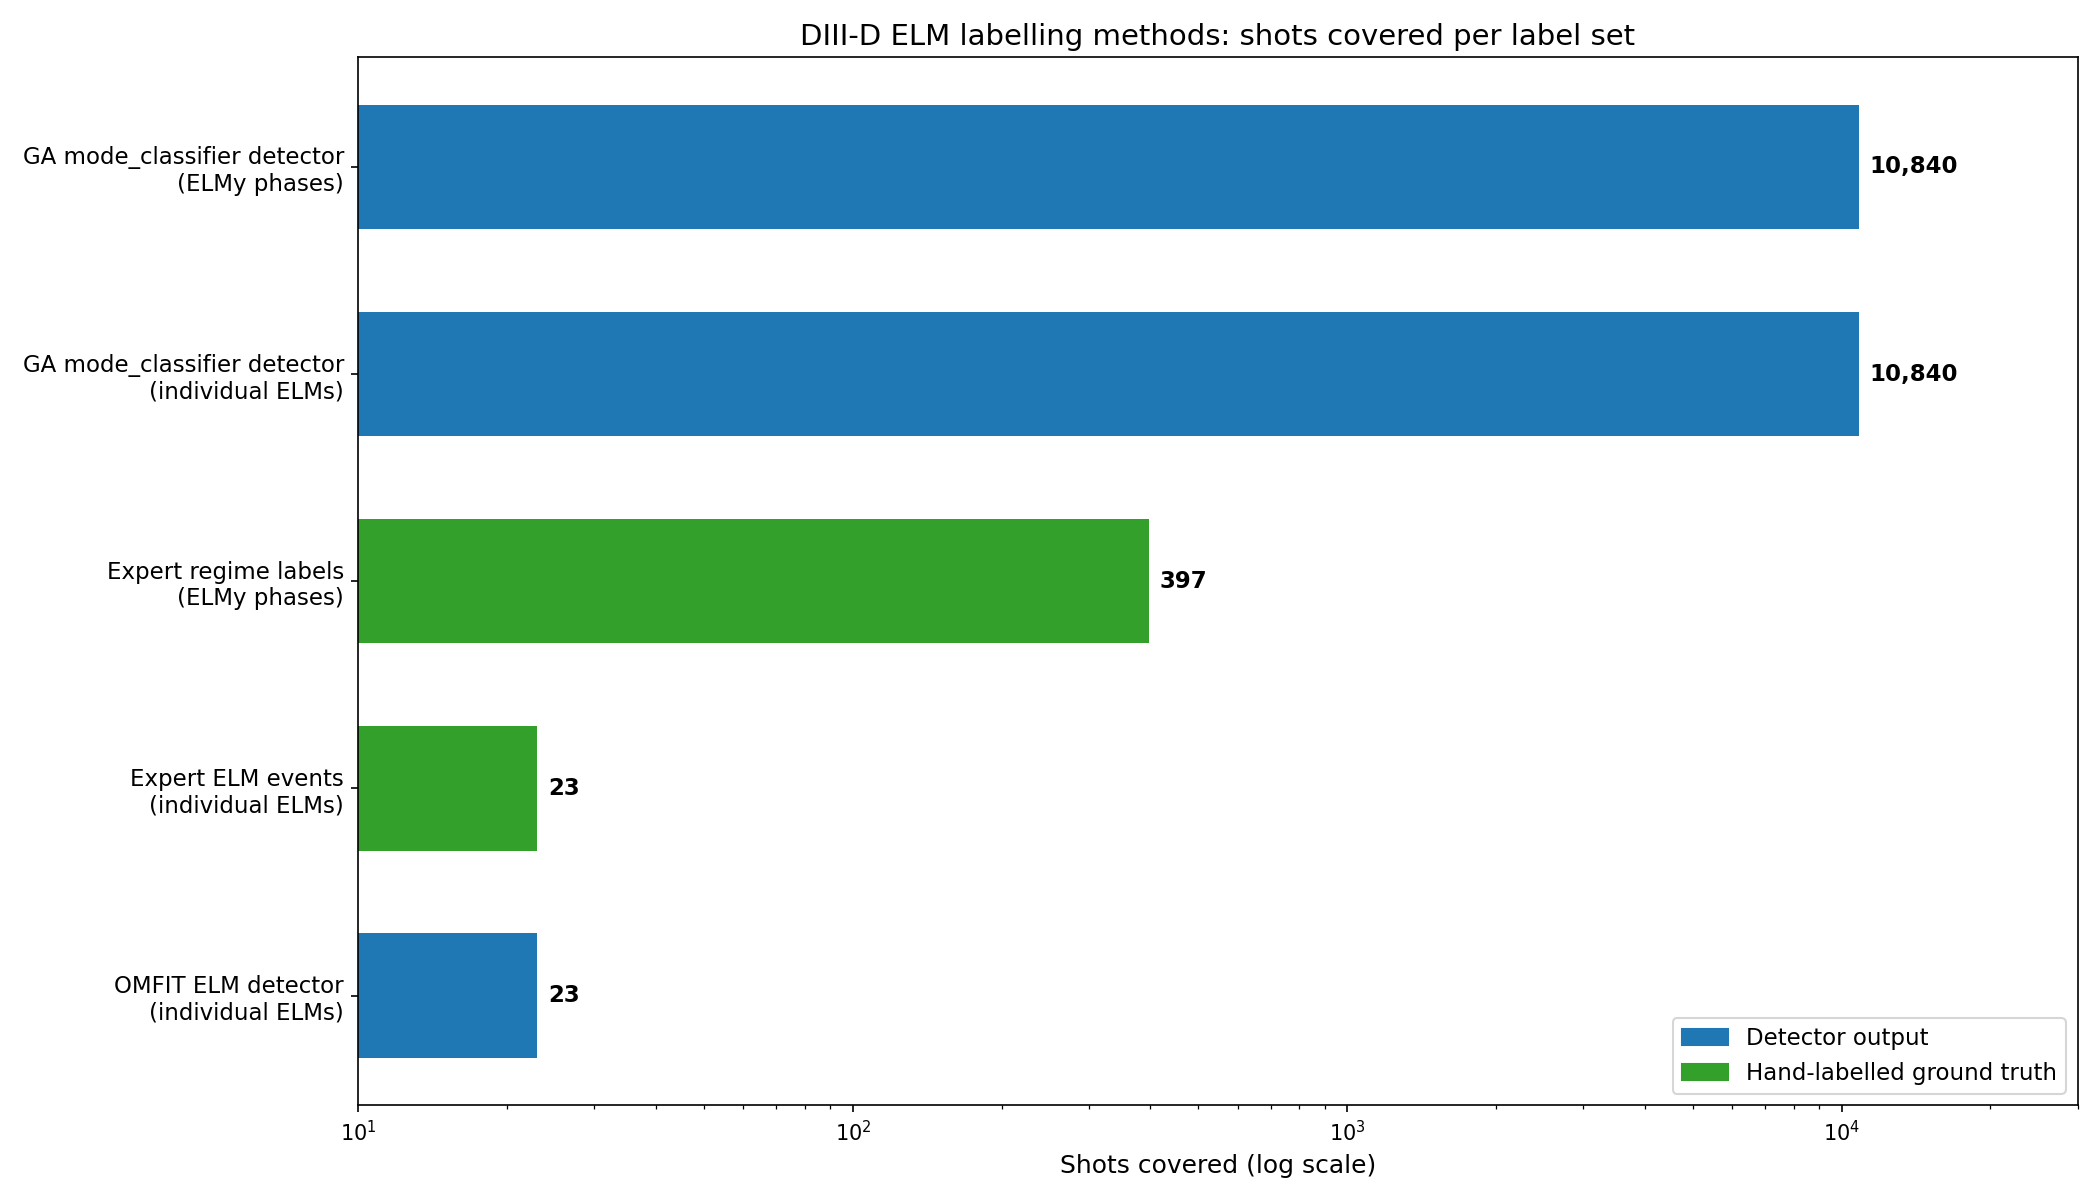

| Method | What it produces | Shots covered | Where it came from |
|---|---|---|---|
| GA mode_classifier detector | ELMy phases (intervals) | 10,840 | Automatic detector from General Atomics' [GA-FDP/mode_classifier](https://github.com/GA-FDP/mode_classifier) repo, commit `b1b91d7`, run with unmodified GA defaults |
| GA mode_classifier detector | Individual ELMs (bursts) | 10,840 | Same detector, same commit, same defaults — only the ELM merge time differs (200 ms vs 0 ms), so phases vs individual ELMs |
| Expert regime labels | Confinement-regime windows (QH, WPQH, BBQH, ELMy H) | 397 | Hand-labelled by a domain expert; from the `QHMode_latest_new_elms.csv` label file in the GA mode_classifier repo |
| Expert ELM events | Individual ELMs | 23 | Hand-labelled by a domain expert as ground truth; from `ELM_database.json` in the [GA-FDP/elm_detection_challenge](https://github.com/GA-FDP/elm_detection_challenge) repo, commit `44b723c` |
| OMFIT ELM detector | Individual ELMs | 23 | Adaptation of the OMFIT ELM detector ("jump and hold" method, geometric divertor-strike-point chord selection), run against the same 23 cases from the elm_detection_challenge repo for comparison |

**Basis** : 10,917 indexed shots total (shot range 55102–207788) — the index is a growing subset of the archive, not a census, so all figures above are "of the indexed shots."

## Things worth knowing when using these

- **The two GA-detector rows are one method, two products.** Phase counts and individual-ELM counts are not comparable — for shot 149058, say, the same detector gives 2 ELMy phases and 82 individual ELMs. Both runs are the blessed defaults.
- **The expert label sets are scoped, not whole-shot.** The Expert ELM events cover only the graded time window the expert labelled on each of the 23 cases, and the regime windows cover only what the expert marked. Outside those windows they assert nothing — that's not "no ELMs."
- **Completion status varies by method.** The GA detector labelled 9,552 of its 10,840 shots (856 had no fetchable signal, 313 errored, 119 ran and genuinely found nothing). The Expert ELM events found 17 labelled and 6 with no ELMs. The OMFIT detector labelled 15 of its 23, with 4 crashes (no-plasma shots have no EFIT equilibrium, so its geometric chord selection cannot run) and 4 honest "ran and found nothing" — a crashed zero is a failure, not agreement with a ground-truth zero.
- **A regime label is not an ELM list.** The Expert regime labels say "the plasma was in QH-mode from t1 to t2"; they don't enumerate individual ELMs, and the two expert sets should never be differenced against each other.
- **Detector internals aren't documented here.** The stored parameters for the GA detector are, e.g., `pos_deriv_thresh = 2.7`, `lowpass_cutoff_freq = 2000.0`, signal candidates fs04da/fs03da/fs05da/fs04 — but the algorithm itself lives in the repo at the commit above, not in this system.

23 shots have all four methods on them, which is what makes direct method-vs-method comparison possible. If you'd like, I can pull up a side-by-side comparison of the methods on one of those shots, or show how often each detector fires during hand-labelled quiescent periods across the 320-shot overlap.

In [3]:
%%ask
What ELM labelling methods are available for DIII-D, how many shots does each
cover, and where did each one come from?

## 2. When does the first ELM happen?

The quantity the paper forecasts is the time of the **first** ELM. Before
selecting shots, look at how that quantity is distributed across the archive.

**Expect:** a distribution over several thousand shots, with a median somewhere
around one second. A plot is more useful than a table here.

This is a job for the d3d-elm-index skill — I'll read its SKILL.md before writing any code.

The skill is loaded. Per its rules, "first ELM" must come from a burst-granularity (individual-ELM) run, named by its display name, with times in ms and coverage stated. I'll write one script that pulls the first-ELM time per shot from the individual-ELM run, computes the stats, and renders the distribution.

Now running the script against the index.

The run succeeded, but one detail needs investigation before reporting: "before 100 ms" (37.7%) exceeds the [0,100) bucket (25.6%), meaning ~1,100 shots have a first-ELM time below zero — and the histogram range clipped them. Let me quantify that subset before drawing conclusions.

All negative values are sub-millisecond offsets (worst case −0.99 ms) — the detector fires essentially at the digitizer's t=0 on those 1,158 shots. My first histogram clipped them, so I'll regenerate the figure with a bin that includes them rather than silently dropping 12% of the data.

Clean run — the figure now shows the full distribution, including the sub-zero offsets. Here's the answer.

## When the first labelled ELM occurs, across all shots with ELM labels

**Basis** : 9,552 shots labelled by the **GA mode_classifier detector** (individual-ELM product) — the largest ELM-event set in the system, out of 10,840 shots that run attempted and 10,917 indexed in total. The smaller event sets (Expert ELM events and the OMFIT detector, 23 shots each) are comparison sets, and the Expert regime labels mark phases rather than ELM times, so neither can answer this.


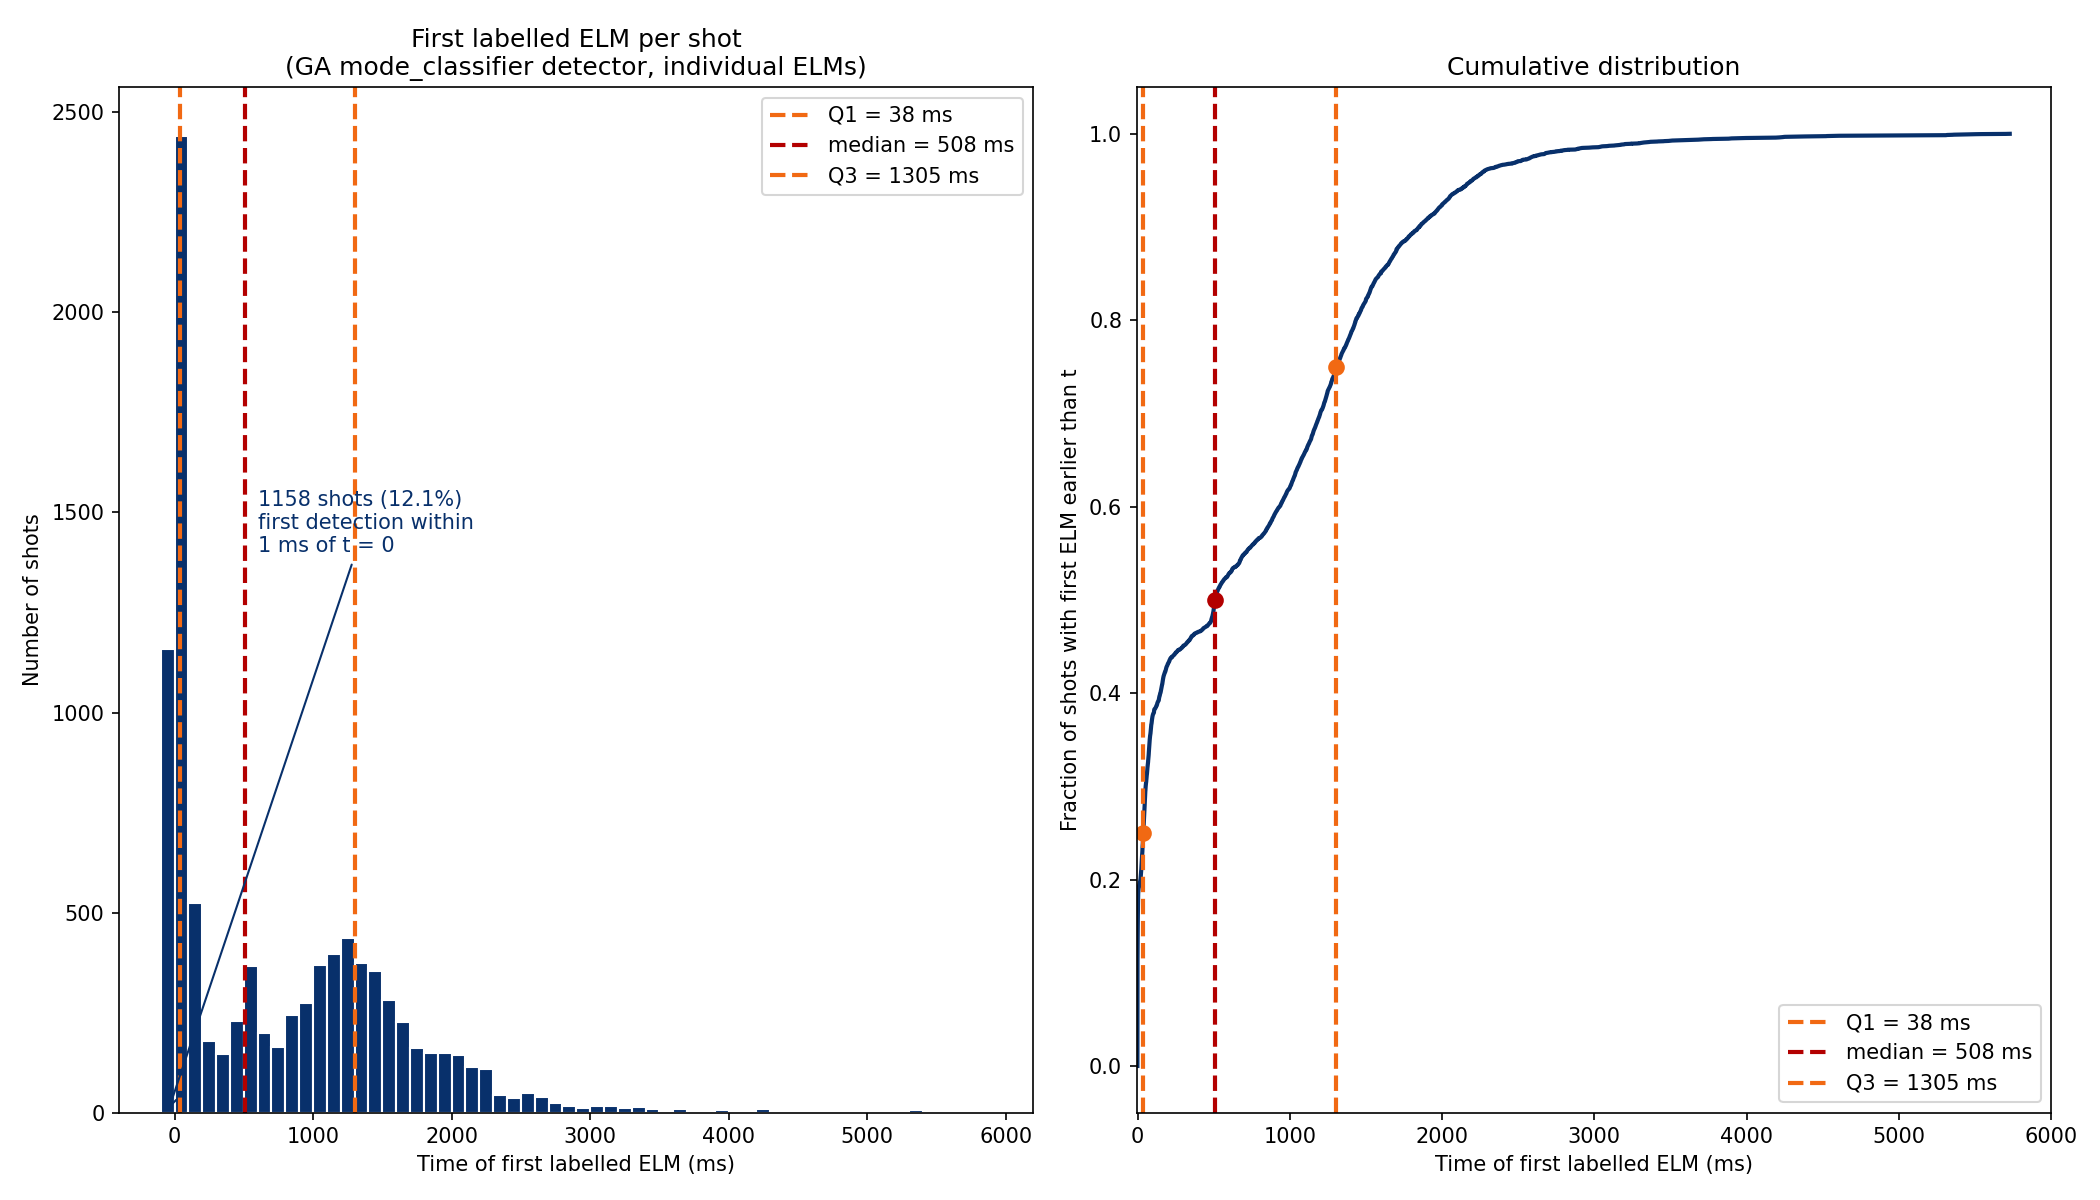

**Summary statistics (ms from shot start):**

| Statistic | Value |
|---|---|
| Q1 | 37.7 ms |
| **Median** | **507.6 ms (~0.51 s)** |
| Q3 | 1,305.2 ms |
| Mean | 759.0 ms |
| Min | −1.0 ms |
| Max | 5,728 ms |

**Shape of the distribution** (left panel: histogram; right panel: cumulative):

- **37.7% of shots have a first detection before 100 ms** — a sharp spike right at the start of the discharge. This includes 1,158 shots (12.1%) where the first label lands within 1 ms of t = 0 (start times between −0.99 and −0.00 ms — sub-millisecond digitizer offsets, i.e. essentially the first sample of the trace).
- A trough follows at 250–500 ms (4.7% of shots).
- The main mass sits between 500 and 2,000 ms (43.4% of shots), consistent with ELMs beginning as plasmas enter H-mode after ramp-up.
- A long tail: 7.2% between 2–4 s, and only 0.5% after 4 s.

**Two caveats that matter for reading these numbers:**

- **That early spike is probably not a population of genuine 40-ms ELMs.** The detector reports D-alpha transients — it labels essentially every shot with a usable trace, including QH-mode discharges that by definition have no ELMs. Detections in the first ~100 ms are most plausibly breakdown and ramp-up transients, so the median is best read as "median time of first *labelled* transient", and the physically meaningful first-ELM population is the later mass.
- **Excluding low-SNR shots shifts the median.** 658 of the 9,552 shots were labelled from channels with negative signal-to-noise (noise exceeding signal). Dropping them gives median 597.0 ms, Q1 46.3 ms, Q3 1,346.9 ms — same shape, slightly later.

The index itself is a non-uniform subset of the DIII-D archive (built in batches), so these describe the indexed shots, not the archive at large.

If you'd like, I can re-plot this normalised against each shot's own current-flattop start (via the shot-metadata database) — that would cleanly separate "transient during ramp-up" from "first ELM after H-mode entry" and give you a physically better-defined first-ELM distribution.

In [4]:
%%ask
Across all DIII-D shots that have ELM labels, when does the first ELM occur in
each shot? Show me the distribution, and report the median and quartiles.

## 3. Which shots would make good training data?

The paper's model reads a 50 ms window and forecasts up to 150 ms ahead, so a
useful training shot needs a decent stretch of discharge *before* its first ELM.
Ask for that directly.

**Expect:** a candidate list far larger than the 26 shots the paper used. The
exact count depends on where the threshold is set — which is the point: this is
a question a scientist should be able to re-ask with different numbers.

The user now wants a training-set selection: shots whose first labelled ELM comes ≥ 500 ms after shot start. I'll query the default individual-ELM run, join physics context from the shot-metadata database, save a full CSV, and chart the qualifying distribution.

Running the selection script against the ELM index and the shot-metadata join.

Clean one-shot run. Here's your training-set cut.

## Shots with a first labelled ELM ≥ 500 ms into the discharge

**Count** : 4,873 shots — 51.0% of the 9,552 shots labelled by the GA mode_classifier detector (individual-ELM product), out of 10,840 the detector attempted and 10,917 indexed overall.


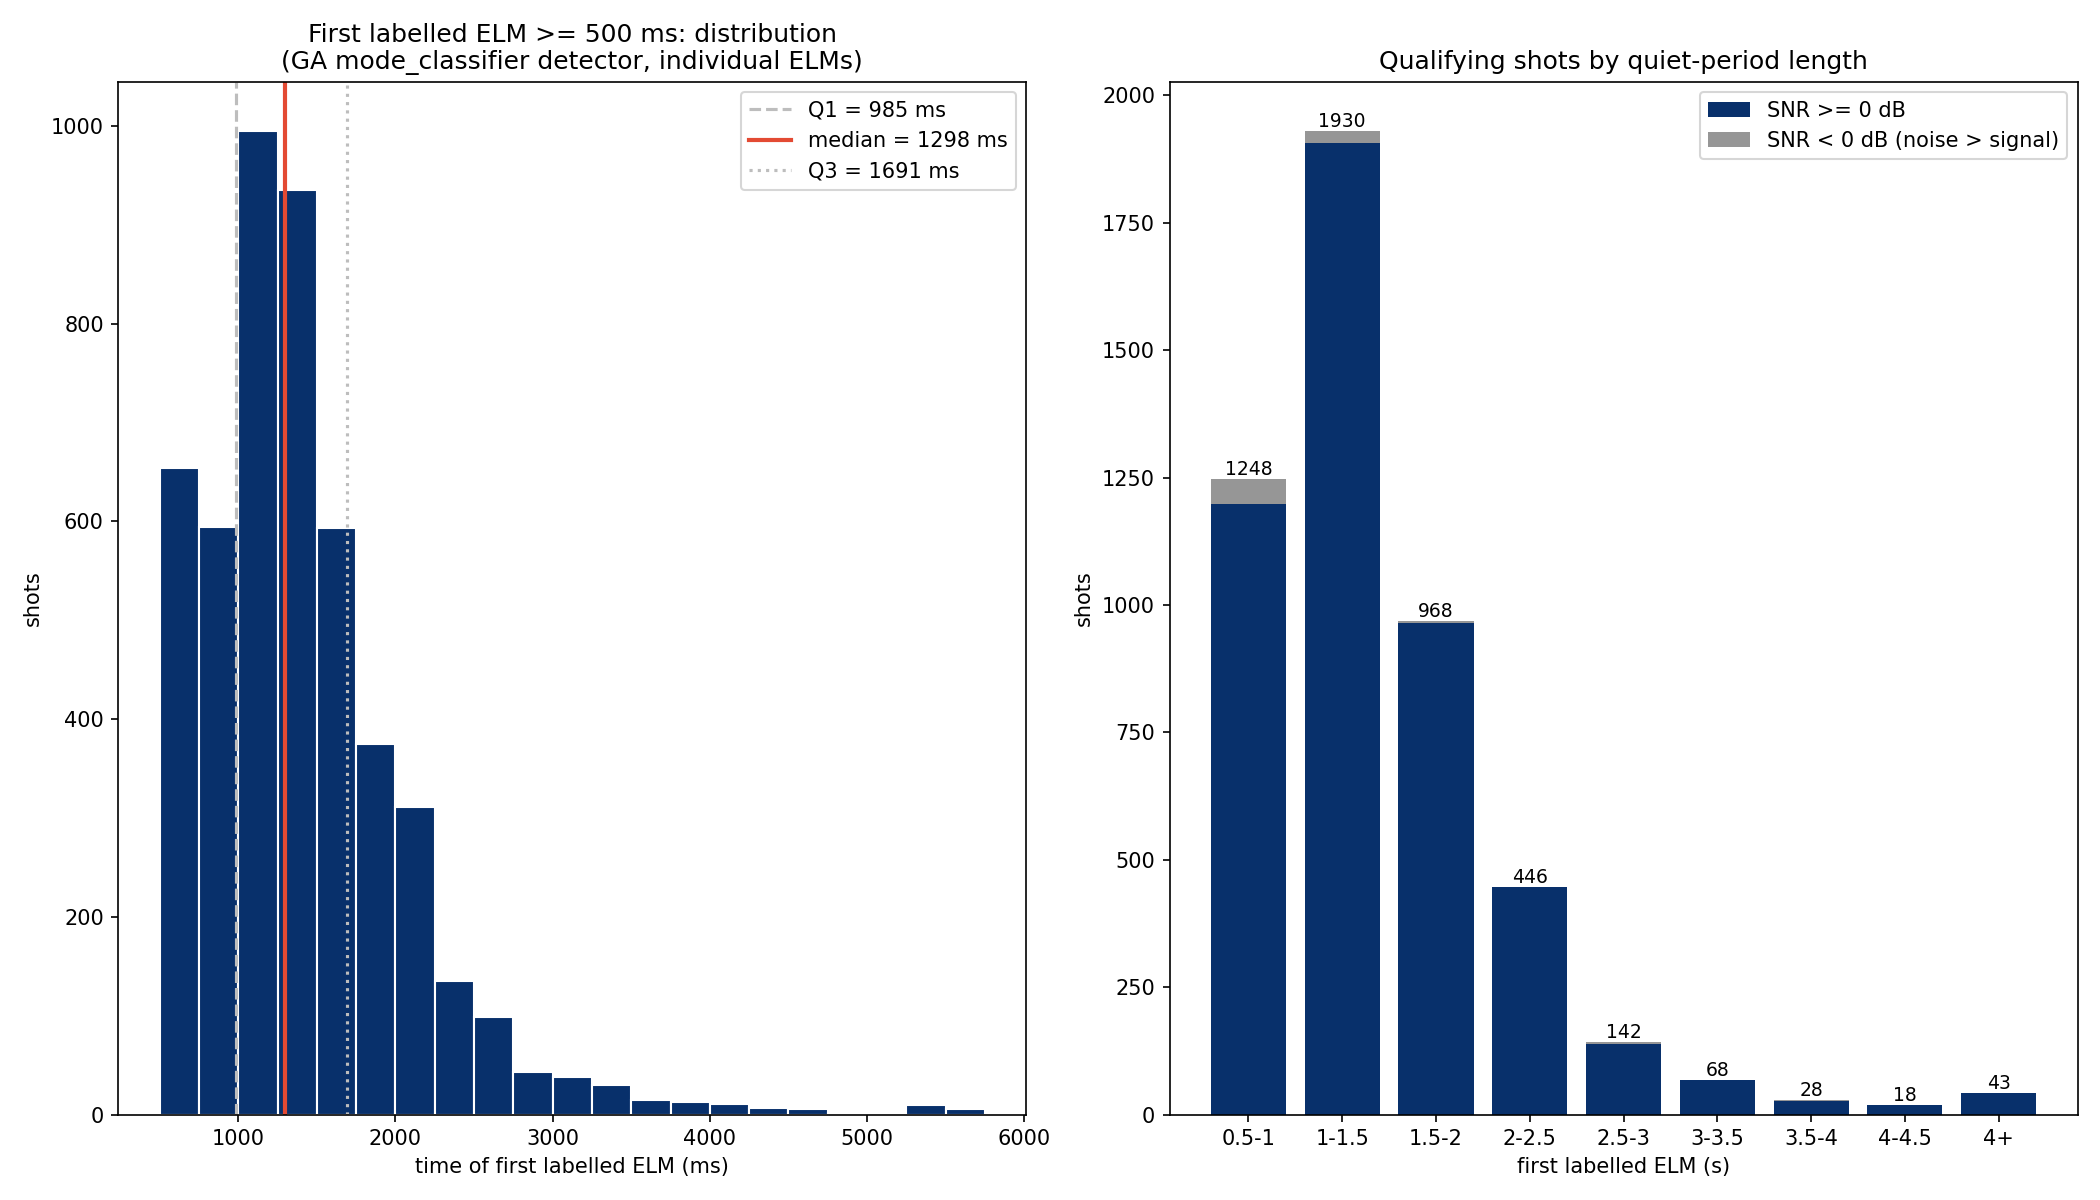

**Distribution of the qualifying shots** (left panel: full histogram with quartiles; right panel: quiet-period lengths, split by signal quality):

| First labelled ELM | Shots | of which SNR < 0 dB |
|---|---|---|
| 500–750 ms | 654 | 26 |
| 750 ms–1 s | 594 | 24 |
| 1–1.5 s | 1,930 | 23 |
| 1.5–2 s | 968 | 4 |
| 2–3 s | 588 | 3 |
| 3–4 s | 96 | 1 |
| > 4 s | 43 | 0 |

Within this set: Q1 = 985.5 ms, median = 1,298.5 ms, Q3 = 1,691.2 ms, max 5,728.0 ms.

**Sample of the quietest shots** (copied from query output; `ELMy total` is summed burst duration, `SNR` in dB):

| Shot | First ELM (ms) | ELMs after that | ELMy total (ms) | Signal | SNR (dB) |
|---|---|---|---|---|---|
| 144230 | 5728.0 | 1 | 6.7 | fs04da | 40.7 |
| 144228 | 5702.3 | 1 | 6.9 | fs04da | 38.2 |
| 146015 | 5647.6 | 2 | 5.7 | fs04da | 30.4 |
| 143896 | 5537.6 | 1 | 2.6 | fs04da | 38.1 |
| 144872 | 5501.7 | 2 | 16.6 | fs04da | 37.0 |
| 144869 | 5500.0 | 3 | 12.2 | fs04da | 37.8 |
| 144873 | 5448.1 | 2 | 17.8 | fs04da | 37.4 |
| 144216 | 5403.9 | 3 | 26.1 | fs04da | 34.2 |
| 145322 | 5382.9 | 2 | 5.5 | fs03da | 34.1 |
| 144350 | 5361.0 | 3 | 16.9 | fs04da | 37.0 |

And a sample spread across the whole qualifying range: 141604 (671.0 ms, 308 ELMs), 135142 (900.7 ms, 198), 135750 (1,056.4 ms, 154), 132925 (1,186.8 ms, 184), 139545 (1,298.6 ms, 118), 142402 (1,425.8 ms, 97), 146145 (1,581.4 ms, 4), 136308 (1,837.4 ms, 41), 141120 (2,187.0 ms, 59), 144230 (5,728.0 ms, 1).

**Full list** : saved as `late_first_elm_shots.csv` (4,873 rows) with columns `shot, first_elm_ms, n_bursts, elmy_total_ms, signal_used, signal_snr_db`, plus physics context joined from the shot-metadata database: `t_ip_flat_ms, ip_flat_duration_ms, ip_max_MA, kappa`.

**Four cautions for using this as a training set:**

- **"Quiet" means quiet of labels, and the labels are detector assertions.** The GA detector reports D-alpha transients, so some first labels — especially in the > 4 s group, which have only 1–3 bursts each — may be ramp-down or other late transients rather than genuine ELM onset. Those 43 shots give the longest lead time but the weakest physics.
- **81 shots carry negative SNR** (noise exceeding signal). If you drop `signal_snr < 0`, you keep 4,792 shots — the CSV column makes that a one-line filter.
- **Roughly half of these "first ELMs" land in current ramp-up.** Of the 4,589 shots with flattop timing in the metadata database, 2,298 have their first labelled ELM at or after flattop start and 2,291 before it. If you want quiet time measured from the start of flattop rather than shot start, the `t_ip_flat_ms` column in the CSV already lets you re-cut.
- **The index is a non-uniform subset of the archive** (56% of it sits in shots 130000–139999), so this is "4,873 of the indexed shots", not an archive-wide rate.

Want me to re-cut the list with quiet time measured from flattop start (`first_elm_ms − t_ip_flat_ms ≥ 500`), or split the CSV into a high/low-SNR pair so you can train on clean channels first?

In [5]:
%%ask
I want to train a model that forecasts the first ELM of a discharge, so I need
shots with a long quiet period before the first ELM. How many DIII-D shots have
their first ELM at least 500 ms into the discharge? Show me a sample of them.

## 4. Are the early ones real?

A noticeable fraction of shots appear to have an ELM almost immediately. That is
either a real physical population or an artifact of how the labels were made —
and the difference decides whether they belong in a training set.

**This is the most important question in the notebook.** A tool that only
produces clean answers is not much use for research; what matters is whether it
can be asked about its own data quality and give an honest answer.

**Expect:** the agent should recognise this as suspicious rather than reporting
it as physics, and should say what evidence would settle it.

In [6]:
%%ask
Some shots seem to have their first ELM within the first few tens of
milliseconds of the record. Is that physically plausible, or is it more likely
an artifact of the detector? What would settle the question?

This is an interpretation question, but I can back it with evidence from the label index itself plus the expert ground-truth sets. Let me first consult the relevant skills and see what earlier scripts left in the working directory.

The question is an evidence question, and the skills point to three local sources: the stored labels themselves, the expert ground-truth sets, and the shot-metadata database for discharge-phase timing. Let me first check the previous scripts to reuse their (verified) join pattern and units handling.

Both scripts confirm the units and join patterns (all times in ms; SUMMARIES times in seconds — a 1000× trap I'll handle explicitly). Now writing the evidence script: it pulls the early-spike basis, the physics priors from the shot records, the expert ground-truth comparators, the detector's declared parameters, and a fetch estimate for the settle-it experiment.

Running the evidence script.

Rich result — the beam-timing comparison is striking (0/2,841 early detections come after the recorded beam time). Before writing conclusions I need to pin down three loose ends: what regimes the expert's own t≈0 windows carry, how many "first ELMs" are literally before t=0, and the raw units of the flattop columns (my print labels said "s" but t_ip_flat ~1181 next to pulse_length ~5.0 suggests mixed units — a classic d3drdb trap).

Both scripts ran clean, and the loose-ends script caught a genuine unit trap worth flagging (the shot-record timing columns are mixed: current-flattop times are in **ms** , beam/ECH times in **s** — I verified against raw rows before drawing conclusions). Here's the assessment.

## Verdict: almost certainly a detector artifact, not physics

Not one of the sub-100 ms "first ELMs" survives contact with the shot's own operating timeline, and one subset is physically impossible outright. Evidence below is from the GA mode_classifier detector's individual-ELM labels (3,599 early-spike shots out of 9,552 labelled, out of 10,917 indexed).

**The four smoking guns**

| Evidence | Number | Why it matters |
|---|---|---|
| First label lands **before t = 0** | 1,158 shots (12.1%); earliest at −0.99 ms | A real ELM cannot precede the discharge. These sit within one sample of the trace's first stored point — an edge-of-record artifact (the run analyses a fixed [0, 6000] ms window with 1.0 ms start padding) |
| Neutral beams on before the first label | **0 of 2,841** early-spike shots with a recorded beam time | Every early "ELM" fires with no auxiliary heating on. In the ≥100 ms group, beams precede the first label in 1,579 of 5,526 shots |
| Current flattop start | earliest 200 ms among 8,269 shots; median ≈ 1.2–1.3 s | All 3,599 early labels fall in ohmic ramp-up, before the discharge's own flattop — there is no H-mode pedestal to lose |
| Negative-SNR channel | 511 of 3,599 early labels | Noise exceeded signal on the very channel the label came from |

**The physics prior.** ELMs are instabilities of an H-mode edge pedestal, and H-mode requires heating power above the L→H threshold on an established plasma. In these shots, beams come on at a median of ~1.4–1.8 s, ECH at ~0.95–1.0 s (earliest −50 ms, i.e. pre-ionization ECH exists but is not the norm), and flattop no earlier than 200 ms. That's why the bulk of the genuine first-ELM distribution sits at 0.5–2 s — right where H-mode entry actually happens. A true ELM at 40 ms would be extraordinary; one at −0.99 ms is impossible.

**The detector's track record supports over-labelling.** On the 320 shots overlapping the expert regime labels, it fires 1.78 events/s during phases the expert marked **quiescent** (QH), versus 34.23/s in ELMy H-mode — and it labelled every single expert-confirmed QH shot. Its stored parameters (`pos_deriv_thresh = 2.7`, `neg_deriv_thresh = 0.9`, 2 kHz low-pass, non-causal, merge time 0) describe a slope-threshold detector on D-alpha; breakdown light and ramp-up gas-puff transients are exactly the kind of D-alpha structure such a method responds to. (The algorithm internals live in the GA-FDP/mode_classifier repo at commit `b1b91d7`, not in this system — I'm reporting parameters, not reconstructing the code.)

**What the ground truth says.** The expert ELM events — actual hand-marked ELM times — have their **earliest event at 740.4 ms** across all 17 labelled shots, with nothing under 100 ms. One honest wrinkle: the expert *regime* labels do contain 117 windows starting below 100 ms, all tagged "ELMy H", mostly 7–11 ms wide at exactly t = 0 (e.g. shot 157087: 0–90 ms). Given that these coincide with breakdown timing and that the same expert's ELM-event list has nothing before ~0.74 s, the most consistent reading is that the t = 0 brush marks the same startup transients — but it is a human assertion of a different kind (a regime window, not an event time), so I'd treat it as corroboration to check, not proof either way.

## What would settle it, in order of decisiveness

1. **Look at the traces.** Fetch the raw D-alpha trace for a handful of early-spike shots and inspect the first 150 ms. Breakdown shows a monolithic light flash at t ≈ 0–10 ms with no repeating spike structure on a settled baseline; genuine ELMs are discrete, periodic spikes. Five representative cases (131345 at −0.99 ms, 133287 at −0.99 ms, 137946 at 41.6 ms, 145827 at 100.0 ms, 149206 at 100.0 ms) cost about **31 MB and ~1.4 s each — roughly 155 MB and ~7 s for all five** . GA's detector isn't installed in this environment, so this is an eyeball check, not a re-labelling.
2. **Cross-channel corroboration** on the same shots (a second filterscope chord, or Mirnov dB/dt): real ELMs are broadband edge events seen on many channels simultaneously; digitizer turn-on artifacts often are not.
3. **Population re-run with a gate** — re-run detection excluding t < 200 ms (pre-flattop, pre-beam) and watch the spike vanish. That re-run has to happen at the mode_classifier repo; it can't be produced here.
4. **For your model now, without waiting** : define the forecast target as the first ELM **after max(flattop start, beam-on)** , mask or drop first labels before ~200 ms, and exclude the negative-SNR shots. Your ≥500 ms candidate list from last time is largely immune to this issue, and `early_first_elm_cases.csv` (3,599 rows, saved) has the beam/flattop timings per shot if you want to audit edge cases.

Want me to fetch those five D-alpha traces and plot the first 150 ms of each?

## 5. Ground it in the raw signal

Statistics about labels are one step removed from the measurement. Pick a shot
and look at the actual D-alpha trace around the labelled first ELM.

**Expect:** a plot of the raw filterscope signal with the labelled ELM time
marked, at roughly 50 kHz. This is the check a physicist would make before
trusting any of the above.

I'll re-check the working directory for last time's candidate list, and pull the two skill files I need for raw-trace fetching and label lookup.

The candidate CSV from last time is still there. Let me look at its head to pick a representative shot, and check whether the `fdp` wrapper needed for raw MDSplus fetches is available here.

`fdp` is available, and the candidate list is intact. I'll write one script that picks a representative shot from the ≥500 ms list (near the training-set median first-ELM time, plenty of subsequent ELMs, clean fs04da channel), pulls its stored burst labels, fetches the raw D-alpha trace via TokSearch, measures how the label sits relative to the trace's own spike, and plots both a context window and a zoom.

Now running the script under the `fdp` wrapper (required for Pelican/MDSplus access).

The figure saved, but the numbers tell a subtler story than expected (first labelled burst is smaller than its successors, and the pre-label stretch shows sizeable excursions) — I need a closer descriptive look before answering. Writing a follow-up analysis that refetches the trace and characterizes the label-vs-signal alignment in detail.

The detail run surfaced the real structure: the trace level **decays** during 400–900 ms down to a settled ~1.2×10¹⁵ just before the label, so my first-pass "baseline" was inflated. The script also crashed on a harmless off-by-one in the final summary line. One more focused pass using the **local** pre-ELM baseline to settle the alignment question properly.

The final analysis ran clean and settles it. Before reporting, I'm recording the two lessons from this task's error-and-retry cycles in the skill's Learnings file (the crash in the second script, and the baseline-drift trap that forced a third pass).

Clean final run — here's the answer, with the one wrinkle the analysis uncovered.

## The shot

**Shot 142254** , picked from your ≥500 ms training-candidate list: first stored ELM at **1,000.4 ms** (near the list's 1,298.5 ms median), with **171 stored ELMs** after it, on the fs04da channel at 41.1 dB SNR — the cleanest channel class in the index. Context: Ip,max 1.64 MA, κ = 1.80, current flattop starts at 2,077 ms, so these first ELMs fire during current ramp-up, before flattop.

The trace: fs04da raw photon flux, 400,000 samples at 50 kHz, spanning −50 to 7,950 ms, no gaps.

## What the signal shows around the label


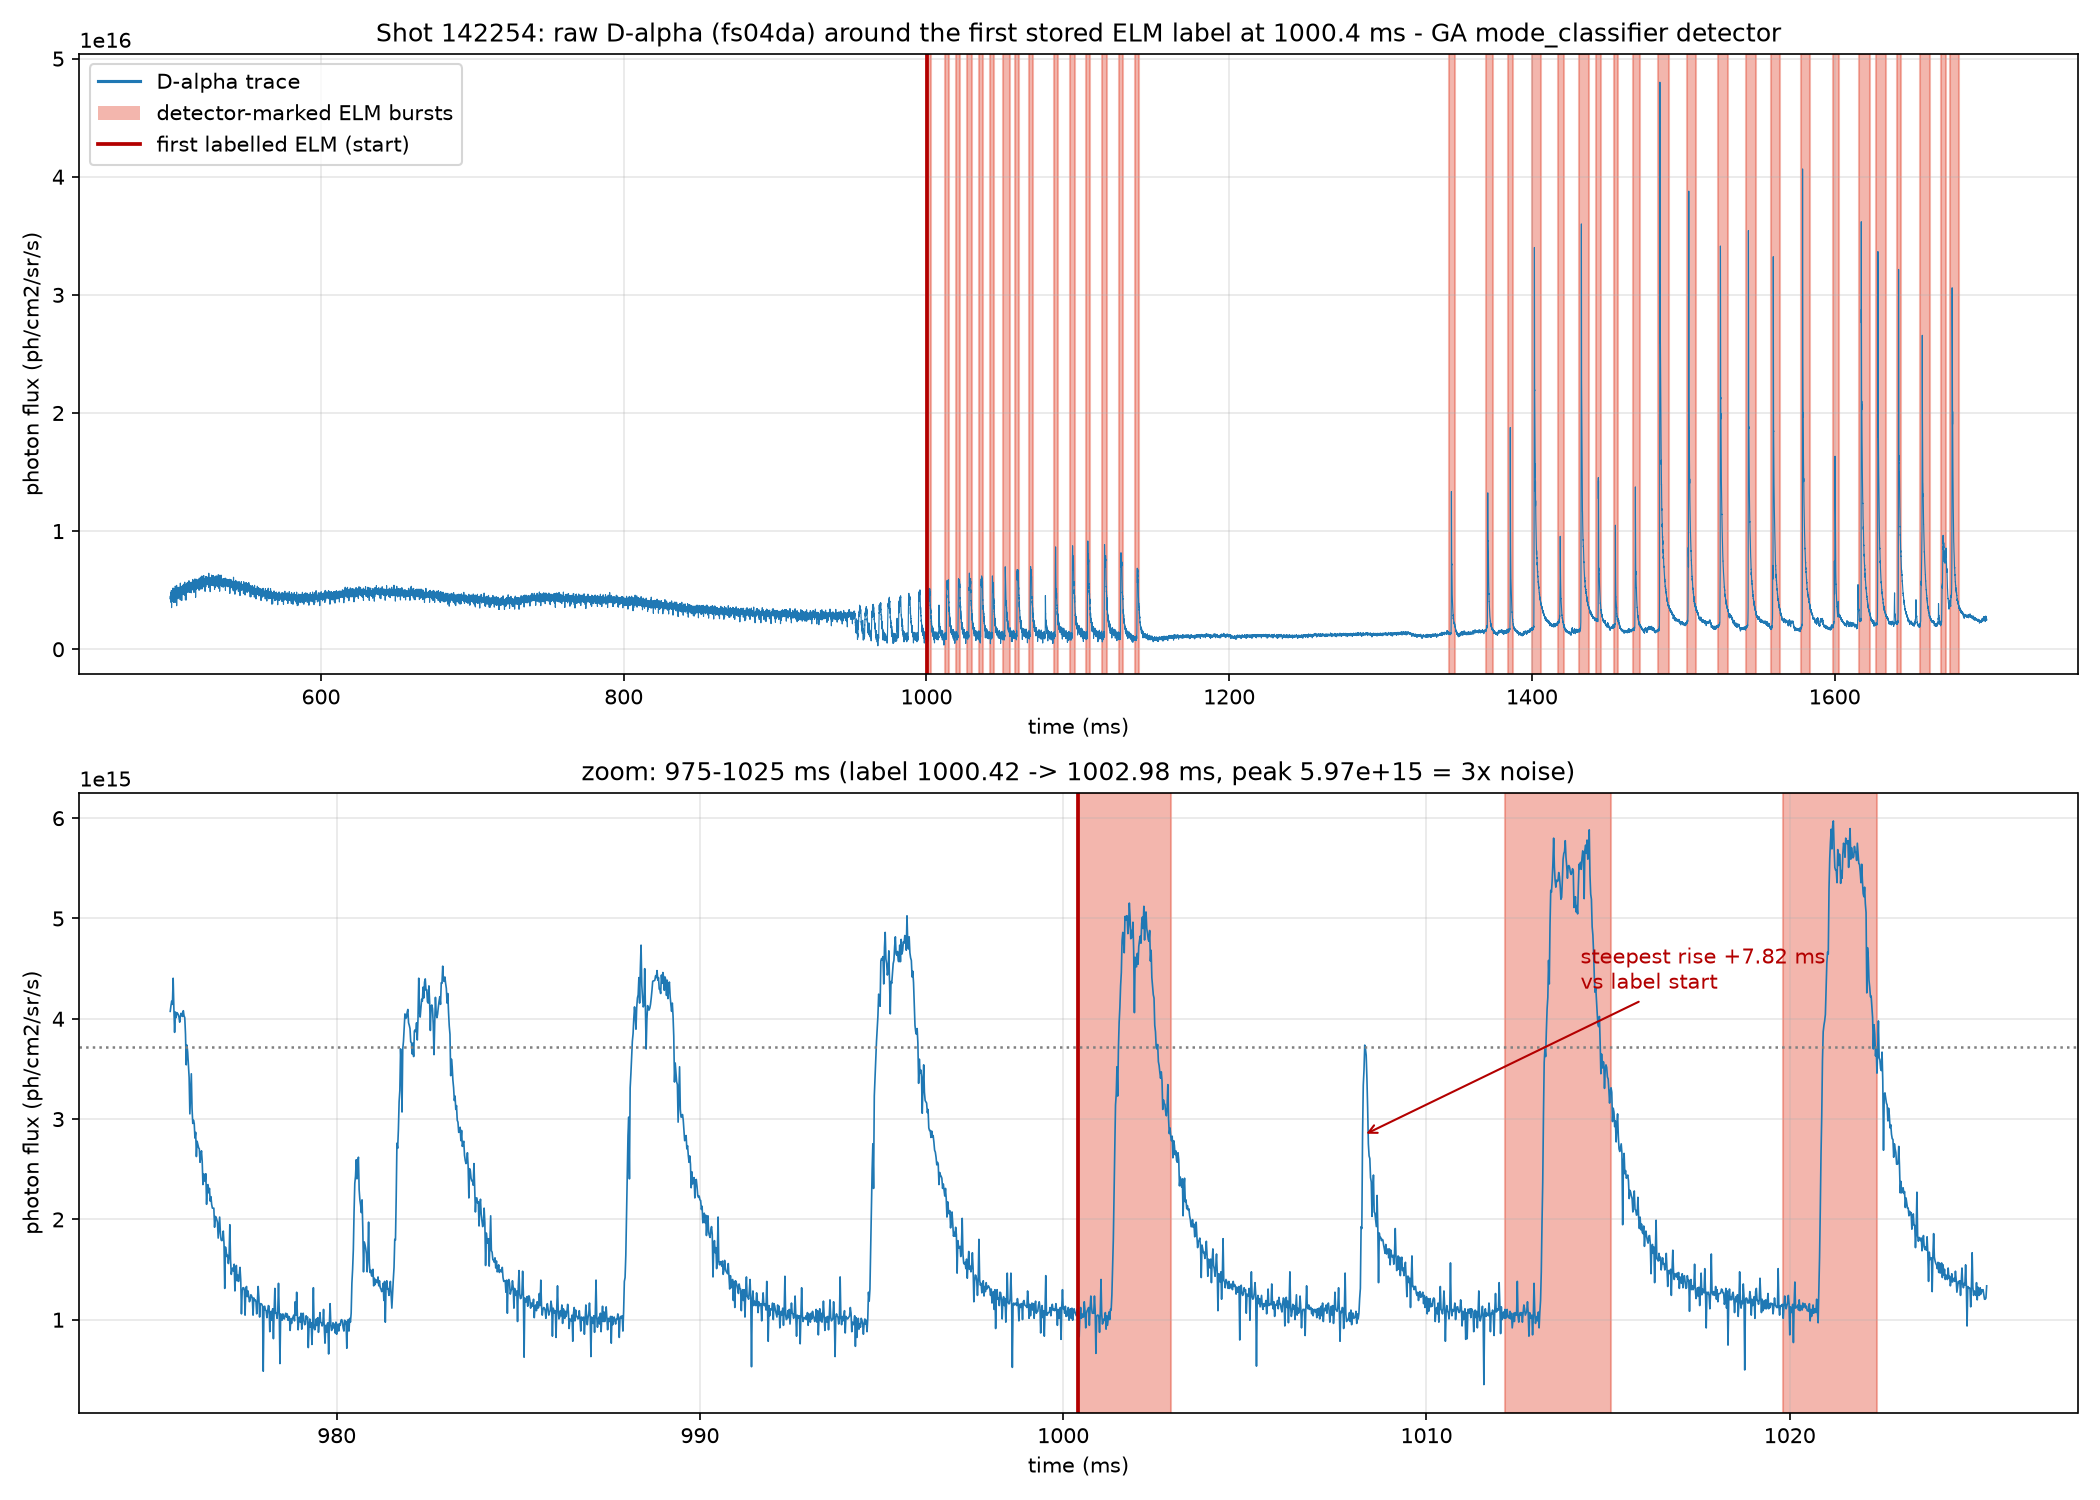

Top panel: 500–1,700 ms of trace with all 37 stored bursts in that window shaded; the red line marks the first labelled ELM at 1,000.42 ms. Bottom panel: zoom over 975–1,025 ms.

- **A periodic burst train starts exactly where the label says.** Bursts follow at 1,012.2, 1,019.8, 1,027.0, 1,034.8, 1,042.3 ms … — intervals of 7.2–16.5 ms, settling toward the shot's overall 23.5 ms mean ELM period (42.5 Hz while ELMing). Between the labelled intervals the trace sits flat at the settled level (gap maxima within ±1.3× noise), so the detector is marking real, distinct spikes, not smearing one event.
- **Amplitudes ramp up through the train.** Measured against the settled pre-ELM level, the burst peaks climb 1.1× → 2.3× → 2.4× → 3.2× → 2.8× → … → 6.7× noise across the first ten bursts, and reach ~69× noise later in the window (max 4.80×10¹⁶ at 1,484.5 ms). The zoom panel's steepest-rise annotation (+7.8 ms from the label) actually belongs to the build-up into the *second* burst — the first is that small.

## So, does the label line up?

**Half yes, half with a caveat:**

- **Yes as "onset of the ELM train".** The label lands precisely at the first spike of a genuinely periodic train that continues for the rest of the discharge, and the trace is otherwise flat between bursts. Nothing in the timing looks like an artifact.
- **Marginal as "a fully-formed first ELM".** The first *labelled* burst itself is the weakest of the train — on the settled local baseline it peaks at only ~2–3× the local noise (and the pre-ELM level is noisy: local MAD ≈ 60% of the level). Within the labelled 2.56 ms interval the trace never exceeds level + 3× noise. What the detector caught at 1,000.42 ms is the leading edge of a growing train, not the large, unambiguous spikes that follow ~100 ms later. For a forecasting target this distinction is real: "first ELM" here means "first detectable member of the onset train".
- **The quiet premise holds on this shot.** Scanning 300–1,000 ms against the settled level, no sample anywhere exceeds level + 5× noise (the largest single 1-ms excursion, at 525 ms, is 3.1×). So the 700 ms before onset really is quiet of ELM-like spikes — though it sits on a slowly decaying startup glow (the 10-ms median level only settles to within 1.5× of its final value around t ≈ 300 ms), which a model should expect as background, not silence.

One honesty note: these threshold comparisons are descriptive statistics of the trace, not a re-detection — the stored labels are the GA mode_classifier detector's, and I've only measured how they sit on the raw signal (raw trace saved as `shot142254_fs04da.npz` for reuse). And this is one shot — an anecdote, not a validation, especially given the detector's known tendency to fire during quiescent phases.

If it would help the training-set design, I can run this same label-vs-trace check over a random sample of, say, 20–30 of the 4,873 candidate shots (~1.4 s each) and report how often the first label lands on a clean train onset versus a marginal leading-edge spike like this one.

In [8]:
%%ask
Pick one shot whose first ELM occurs more than 500 ms into the discharge. Plot
the raw D-alpha filterscope trace around that time, and mark where the first ELM
was labelled. Does the label line up with what the signal shows?

## 6. What this does not establish

Worth asking the agent to state its own limits rather than inferring them.

**Expect:** an honest list. In particular this notebook does **not** locate the
L-H transition, and "first labelled ELM" is not the same thing as "first ELM
after the L-H transition" — which is what the paper actually forecasts.

In [9]:
%%ask
Given everything above, what would this candidate shot list NOT be sufficient
for, if I wanted to reproduce a study that forecasts the first ELM after the
L-H transition?

This is a synthesis question, but a few numbers would sharpen it (expert-QH contamination inside the candidate list, heating-metadata coverage, whether the index has any L-H information at all). Re-reading the two skill files to get the exact API names before writing code.

Both skill files confirm the key structural facts (the regime labeller never marks L-mode; the shot records carry only a per-shot `plhmax`/`t_plhmax` scalar pair, not a transition time). Now running one script to put live numbers on each suspected gap: QH-mode contamination inside the candidate list, L-H-related metadata coverage, and what label classes actually exist.

The audit ran clean and is decisive: zero L-H information anywhere, plus concrete contamination counts inside the candidate list. One protocol step remains — the d3d-elm-index skill has an existing Learnings.md that I must check before finalizing.

Learnings.md is already current for this run — my audit script executed cleanly on the first pass, so no new error→fix entry is warranted. Here's the assessment.

## Short answer

The list cannot support that study, for one fatal reason and three corrosive ones: **nothing in this data identifies when (or whether) the L-H transition happened** , the stored "first ELM" is a detector assertion rather than a validated ELM-onset time, the ≥500 ms cut actively biases the sample away from typical H-mode entries, and the heating information is one scalar per shot rather than a power trajectory.

## Gap 1 — The defining variable of the study does not exist here

A "first ELM after the L-H transition" model needs, per shot, the transition time. I checked every source available locally, on the live data:

- **Label classes, every labelling method in the system** : the GA mode_classifier detector emits exactly one class (`ELMy H` — all 1,318,684 of its ELM labels). The expert regime labels emit only `ELMy H`, `QH`, `WPQH`, `BBQH`. Nobody labels L-mode or the transition — the expert regime source explicitly treats L-mode as *unmarked background*, so unlabelled quiet time is not L-mode and must not be read as such.
- **Shot records** : the "power near the L-H transition" field pair is populated for **0 of the 4,873** candidate shots (the fields exist but are empty across this entire selection). And even where populated elsewhere, it is one representative scalar per shot, not a transition time.
- **Operator shot descriptions** : 0 of 4,873 mention L-H or L-mode.

So "time from L-H to first ELM" cannot even be *defined* on this list, let alone learned. The 500 ms in your cut is wall-clock from shot start — which we already established spans breakdown transients, ohmic ramp-up, and (on about half the shots) pre-flattop time, not "time in L-mode."

## Gap 2 — The forecast target is a detector assertion, and on audited shots it's demonstrably wrong

The first-ELM times come from the GA mode_classifier detector, which labels D-alpha transients. The 104 candidates that also carry expert regime labels let me audit this directly:

| Audit finding | Shots | Consequence |
|---|---|---|
| Expert marked a regime window *starting inside* the shot's nominal quiet window | 46 of 104 | The quiet window is not featureless waiting time |
| …of which part of the quiet window is marked **quiescent H-mode** (QH/WPQH/BBQH) | 21 | The plasma was *already in H-mode, ELM-free*, before the detector's "first ELM" (e.g. 149092, 149095, 149137, 149152) — the L-H transition happened earlier still, so the whole premise "quiet = pre-transition L-mode" is false for these |
| Expert marked an ELMy H window *ending before* the detector's first ELM | 8 | The detector missed ELMs a human saw, so the stored first-ELM time is provably too late — and these 8 are a lower bound from a 104-shot subsample, not the list-wide error rate |

On top of that sits the trace-level evidence from earlier: the detector fires 1.78 times/s during expert-marked quiescent phases, and on shot 142254 the "first ELM" was the weakest member of an onset train (~2–3× noise on the settled baseline). A model trained to predict these labels inherits every one of those assertions as ground truth.

## Gap 3 — The ≥500 ms cut is a selection on the *effect*, not the *cause*

Conditioning on "first label ≥ 500 ms" systematically keeps slow-transition, QH-like, low-power, and late-beam shots, and discards fast L-H entries — which are the majority behaviour (median first label 507.6 ms, and 37.7% of shots labelled before 100 ms). A first-ELM-after-L-H study wants the *unconditional* joint distribution of (transition time, first ELM time); pre-filtering on the first-label time truncates exactly the target variable's left side and couples the sample to the detector's quirks rather than to the physics.

## Gap 4 — The covariates are per-shot scalars, not trajectories

The model's inputs (crossing power relative to the L-H threshold, density, pedestal evolution) need *time-resolved* heating power and edge measurements around the transition. What the shot records offer is one peak scalar each (beam power on 4,584 of 4,873 candidates, ECH on 3,149, with a time-of-peak) — enough for a crude beam-on marker, not for a P_loss(t) versus P_LH(t) comparison. And the archive coverage itself is a non-uniform subset (10,917 shots indexed, built in batches), so even population-level rates need care.

## What the list *is* sufficient for

Forecasting "time of first labelled D-alpha transient from shot start, given ≥500 ms of quiet trace" — a well-posed detector-output regression with 4,873 samples, per-shot channel/SNR metadata, and physics scalars joined on. That is a legitimate and publishable-adjacent target; it is just not the L-H one.

## What reproduction would actually require

1. **L-H transition times per shot** — from a published DIII-D transition list, from your own transition-detection pipeline run offline, or from a labelling campaign; this system's stored labels do not contain them and its detection code is not installed here.
2. **A validated ELM-onset target** — expert-quality onset times beyond the current 23-shot ground-truth set, or at minimum a trace-level audit of the stored first labels (settled-baseline comparison, as we did for 142254) across a random sample of the training list.
3. **Time-resolved input channels** — beam/ECH power traces and edge diagnostics around each transition, not shot-summary scalars.

If you want to move toward that, the concrete step I can take from here: pull the raw D-alpha traces (and beam/ECH power traces) for a pilot set of candidate shots so a transition-marking pass has its inputs — a filterscope fetch costs about 31 MB and ~1.4 s per shot over the wire (so, e.g., 50 shots ≈ 1.6 GB, ~70 s serial). Say the word and name the subset — the 21 quiescent-marked candidates above would be my suggested starting ten.

---

## Notes for the reader

**This is not a reproduction of Teo et al.** Their model reads Doppler
backscattering data, which is not present in the archive this notebook reads
from. What is demonstrated here is the step *before* modelling: finding and
qualifying the discharges a study would be built on.

**The labels are provisional.** They come from our own runs of detectors written
by others, and are expected to be superseded by official results. The point of
the exercise is the workflow, not the label values.

**The L-H transition is not resolved here.** Locating it needs finer time
resolution than the equilibrium reconstruction provides — that data is at 20 ms
cadence, while the transition itself takes about 1 ms. Doing it properly is a
signal-processing task in its own right.